# 1-4. EfficientNet-B0 전이학습 모델

직접 촬영한 수업 태도 이미지를 `attentive`, `inattentive`, `drowsy` 3개 클래스로 분류합니다.

- 데이터가 이미 `dataset/train`, `dataset/val`, `dataset/test`로 나뉘어 있으면 그대로 사용합니다.
- 아직 나뉘어 있지 않으면 클래스별로 70/15/15 stratified split을 자동 생성합니다.
- 학습은 1단계 `classifier`만 학습, 2단계 `last feature block + classifier` fine-tuning 순서로 진행합니다.


## 1. 기본 설정과 import


In [29]:
import json
import random
import shutil
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights
from tqdm.auto import tqdm


RAW_CLASS_MAP = {
    "Attentive": "attentive",
    "Drowsy": "drowsy",
    "LookingAway": "inattentive",
}
SPLIT_NAMES = ("train", "val", "test")


@dataclass
class TrainConfig:
    dataset_dir: Path = Path("dataset")
    model_dir: Path = Path("models")
    batch_size: int = 16
    num_workers: int = 0
    image_size: int = 224
    seed: int = 42
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    epochs_freeze: int = 10
    epochs_finetune: int = 5
    lr_freeze: float = 1e-3
    lr_finetune: float = 1e-4
    weight_decay: float = 1e-4
    auto_split: bool = True
    run_finetune: bool = True
    train_augmentation_repeats: int = 4


class RepeatedAugmentationDataset(Dataset):
    """Repeat a transformed dataset so each epoch sees more random augmented samples."""

    def __init__(self, base_dataset: Dataset, repeats: int = 1):
        self.base_dataset = base_dataset
        self.repeats = max(1, int(repeats))

    def __len__(self):
        return len(self.base_dataset) * self.repeats

    def __getitem__(self, index):
        return self.base_dataset[index % len(self.base_dataset)]

    def __getattr__(self, name):
        return getattr(self.base_dataset, name)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def has_split_structure(dataset_dir: Path) -> bool:
    return all((dataset_dir / split).is_dir() for split in SPLIT_NAMES)


def split_dataset(
    dataset_dir: Path,
    seed: int = 42,
    overwrite: bool = False,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
) -> None:
    if has_split_structure(dataset_dir):
        if not overwrite:
            print("이미 train/val/test 구조가 있어 분할을 건너뜁니다.")
            return
        for split in SPLIT_NAMES:
            shutil.rmtree(dataset_dir / split)

    rng = random.Random(seed)
    source_dirs = [path for path in dataset_dir.iterdir() if path.is_dir() and path.name in RAW_CLASS_MAP]
    if not source_dirs:
        raise FileNotFoundError(
            "dataset/Attentive, dataset/Drowsy, dataset/LookingAway 원본 폴더를 찾지 못했습니다."
        )

    for source_dir in source_dirs:
        class_name = RAW_CLASS_MAP[source_dir.name]
        images = sorted(
            path for path in source_dir.iterdir()
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
        )
        if not images:
            print(f"이미지가 없어 건너뜁니다: {source_dir}")
            continue

        rng.shuffle(images)
        test_count = max(1, int(len(images) * test_ratio))
        val_count = max(1, int(len(images) * val_ratio))
        split_groups = {
            "test": images[:test_count],
            "val": images[test_count:test_count + val_count],
            "train": images[test_count + val_count:],
        }

        for split, split_images in split_groups.items():
            target_dir = dataset_dir / split / class_name
            target_dir.mkdir(parents=True, exist_ok=True)
            for image_path in split_images:
                shutil.copy2(image_path, target_dir / f"{source_dir.name}_{image_path.name}")

    print("데이터 분할 완료")


def get_transforms(image_size: int = 224):
    return {
        "train": transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.95, 1.05)),
            ], p=0.7),
            transforms.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.12, hue=0.02),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.5, 2.0)),
        ]),
        "val": transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]),
        "test": transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]),
    }


def create_dataloaders(config: TrainConfig):
    if config.auto_split:
        split_dataset(
            config.dataset_dir,
            seed=config.seed,
            overwrite=True,
            val_ratio=config.val_ratio,
            test_ratio=config.test_ratio,
        )

    transforms_by_split = get_transforms(config.image_size)
    image_datasets = {
        split: datasets.ImageFolder(config.dataset_dir / split, transforms_by_split[split])
        for split in SPLIT_NAMES
    }
    loader_datasets = dict(image_datasets)
    loader_datasets["train"] = RepeatedAugmentationDataset(
        image_datasets["train"],
        repeats=config.train_augmentation_repeats,
    )
    dataloaders = {
        split: DataLoader(
            loader_datasets[split],
            batch_size=config.batch_size,
            shuffle=(split == "train"),
            num_workers=config.num_workers,
        )
        for split in SPLIT_NAMES
    }
    return loader_datasets, dataloaders


def create_model(num_classes: int, freeze_backbone: bool = True, pretrained: bool = True) -> nn.Module:
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def save_class_indices(class_to_idx: dict[str, int], model_dir: Path) -> None:
    model_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        "class_to_idx": class_to_idx,
        "idx_to_class": {str(idx): class_name for class_name, idx in class_to_idx.items()},
    }
    with (model_dir / "class_indices.json").open("w", encoding="utf-8") as file:
        json.dump(payload, file, ensure_ascii=False, indent=2)


def load_class_indices(model_dir: Path) -> tuple[dict[str, int], dict[int, str]]:
    with (model_dir / "class_indices.json").open("r", encoding="utf-8") as file:
        payload = json.load(file)

    if "class_to_idx" in payload:
        class_to_idx = {class_name: int(idx) for class_name, idx in payload["class_to_idx"].items()}
    else:
        class_to_idx = {class_name: int(idx) for class_name, idx in payload.items()}

    idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
    return class_to_idx, idx_to_class


def run_epoch(model, dataloader, criterion, optimizer, device, is_train: bool):
    model.train(is_train)
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for inputs, labels in tqdm(dataloader, leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def fit_model(model, dataloaders, criterion, optimizer, device, epochs: int, phase_name: str):
    history = []
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, dataloaders["train"], criterion, optimizer, device, True)
        val_loss, val_acc = run_epoch(model, dataloaders["val"], criterion, optimizer, device, False)
        history.append({
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        print(
            f"[{phase_name} {epoch:02d}/{epochs:02d}] "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )
    return history


def train_model(config: TrainConfig):
    torch.manual_seed(config.seed)
    image_datasets, dataloaders = create_dataloaders(config)
    save_class_indices(image_datasets["train"].class_to_idx, config.model_dir)

    device = get_device()
    model = create_model(len(image_datasets["train"].classes), freeze_backbone=True).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        (param for param in model.parameters() if param.requires_grad),
        lr=config.lr_freeze,
        weight_decay=config.weight_decay,
    )
    history = fit_model(model, dataloaders, criterion, optimizer, device, config.epochs_freeze, "freeze")

    if config.run_finetune and config.epochs_finetune > 0:
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(
            (param for param in model.parameters() if param.requires_grad),
            lr=config.lr_finetune,
            weight_decay=config.weight_decay,
        )
        history.extend(fit_model(model, dataloaders, criterion, optimizer, device, config.epochs_finetune, "finetune"))

    class_to_idx = image_datasets["train"].class_to_idx
    config.model_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class": {str(idx): class_name for class_name, idx in class_to_idx.items()},
        "config": {key: str(value) if isinstance(value, Path) else value for key, value in config.__dict__.items()},
    }, config.model_dir / "best_model.pt")
    print(f"모델 저장 완료: {config.model_dir / 'best_model.pt'}")
    return model, history


def load_model_for_eval(model_path: Path, device: torch.device):
    checkpoint = torch.load(model_path, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        raw_class_to_idx = checkpoint.get("class_to_idx")
        if raw_class_to_idx is None:
            class_to_idx, _ = load_class_indices(model_path.parent)
        else:
            class_to_idx = {class_name: int(idx) for class_name, idx in raw_class_to_idx.items()}
        state_dict = checkpoint["model_state_dict"]
    else:
        class_to_idx, _ = load_class_indices(model_path.parent)
        state_dict = checkpoint

    idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
    model = create_model(num_classes=len(class_to_idx), freeze_backbone=False, pretrained=False).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, class_to_idx, idx_to_class


def evaluate_test_set(config: TrainConfig):
    _, dataloaders = create_dataloaders(config)
    device = get_device()
    model, _, idx_to_class = load_model_for_eval(config.model_dir / "best_model.pt", device)

    y_true = []
    y_pred = []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloaders["test"], leave=False):
            inputs = inputs.to(device)
            outputs = model(inputs)
            y_true.extend(labels.tolist())
            y_pred.extend(outputs.argmax(dim=1).cpu().tolist())

    class_names = [idx_to_class[idx] for idx in range(len(idx_to_class))]
    accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    matrix = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(cmap="Blues", values_format="d")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    return accuracy, y_true, y_pred


def predict_image(image_path: Path, model_path: Path):
    device = get_device()
    model, _, idx_to_class = load_model_for_eval(model_path, device)
    eval_transform = get_transforms()["test"]

    image = Image.open(image_path).convert("RGB")
    inputs = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(inputs), dim=1).squeeze(0).cpu()

    probabilities = {idx_to_class[idx]: float(probs[idx].item()) for idx in range(len(idx_to_class))}
    predicted_class = max(probabilities, key=probabilities.get)
    return predicted_class, probabilities


# Windows/Jupyter 환경을 고려해 num_workers는 0을 기본으로 둡다.
DATASET_DIR = Path("dataset")
MODEL_DIR = Path("models")

config = TrainConfig(
    dataset_dir=DATASET_DIR,
    model_dir=MODEL_DIR,
    batch_size=16,
    num_workers=0,
    epochs_freeze=10,
    epochs_finetune=5,
    lr_freeze=1e-3,
    lr_finetune=1e-4,
    auto_split=True,
    run_finetune=True,
    train_augmentation_repeats=4,
)

print(f"사용 장치: {get_device()}")
print(config)


사용 장치: cuda
TrainConfig(dataset_dir=WindowsPath('dataset'), model_dir=WindowsPath('models'), batch_size=16, num_workers=0, image_size=224, seed=42, val_ratio=0.15, test_ratio=0.15, epochs_freeze=10, epochs_finetune=5, lr_freeze=0.001, lr_finetune=0.0001, weight_decay=0.0001, auto_split=True, run_finetune=True, train_augmentation_repeats=4)


## 2. 데이터셋 70/15/15 분할

`dataset/train`, `dataset/val`, `dataset/test` 폴더가 없으면 자동으로 생성합니다. 현재 수집 폴더명인 `Attentive`, `Drowsy`, `LookingAway`는 각각 `attentive`, `drowsy`, `inattentive`로 매핑됩니다.


In [30]:
split_dataset(
    DATASET_DIR,
    seed=config.seed,
    overwrite=True,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)


데이터 분할 완료


## 3. ImageFolder와 DataLoader 확인

Train 데이터에만 랜덤 증강을 적용하고, `train_augmentation_repeats`만큼 반복해 한 epoch에서 더 많은 증강 샘플을 보게 합니다. Validation/Test 데이터에는 Resize와 Normalize만 적용합니다.


In [31]:
image_datasets, dataloaders = create_dataloaders(config)

print("class_to_idx:", image_datasets["train"].class_to_idx)
print("train 개수:", len(image_datasets["train"]))
print("val 개수:", len(image_datasets["val"]))
print("test 개수:", len(image_datasets["test"]))


데이터 분할 완료
class_to_idx: {'attentive': 0, 'drowsy': 1, 'inattentive': 2}
train 개수: 1988
val 개수: 105
test 개수: 105


## 4. EfficientNet-B0 모델 생성 확인

ImageNet pretrained EfficientNet-B0를 불러오고 마지막 `classifier` layer를 3클래스 출력으로 교체합니다.


In [32]:
model = create_model(num_classes=3, freeze_backbone=True)
print(model.classifier)
print("학습 가능한 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)
학습 가능한 파라미터 수: 3843


## 5. 학습 실행

1단계는 backbone freeze 후 `classifier`만 학습합니다. 2단계는 마지막 feature block과 `classifier`만 낮은 learning rate로 fine-tuning합니다. Validation accuracy가 가장 좋은 모델은 `models/best_model.pt`로 저장됩니다.


In [33]:
# 시간이 오래 걸리면 epochs_freeze/epochs_finetune 값을 줄여 빠르게 점검할 수 있다.
trained_model = train_model(config)


데이터 분할 완료


[freeze 01/10] train loss 0.7946 acc 0.6730 | val loss 0.5759 acc 0.8762


[freeze 02/10] train loss 0.5676 acc 0.7993 | val loss 0.4555 acc 0.8952


[freeze 03/10] train loss 0.5167 acc 0.8038 | val loss 0.4045 acc 0.8857


[freeze 04/10] train loss 0.4720 acc 0.8275 | val loss 0.3709 acc 0.9143


...

[finetune 01/05] train loss 0.3486 acc 0.8702 | val loss 0.2082 acc 0.9333


[finetune 02/05] train loss 0.2662 acc 0.9069 | val loss 0.1754 acc 0.9524


[finetune 03/05] train loss 0.2304 acc 0.9190 | val loss 0.1542 acc 0.9619


[finetune 04/05] train loss 0.1811 acc 0.9437 | val loss 0.1490 acc 0.9429


[finetune 05/05] train loss 0.1730 acc 0.9381 | val loss 0.1413 acc 0.9333
모델 저장 완료: models\best_model.pt


## 6. Test set 평가

저장된 best model로 test accuracy, classification report, confusion matrix를 출력합니다.


데이터 분할 완료


              precision    recall  f1-score   support

   attentive       0.94      0.94      0.94        32
      drowsy       1.00      0.95      0.97        39
 inattentive       0.92      0.97      0.94        34

    accuracy                           0.95       105
   macro avg       0.95      0.95      0.95       105
weighted avg       0.95      0.95      0.95       105



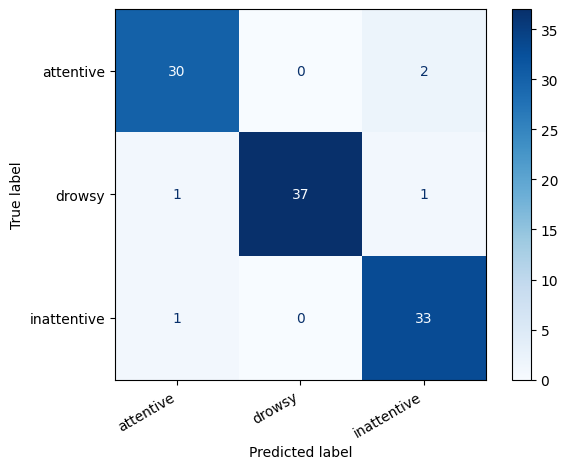

최종 test accuracy: 0.9523809523809523


In [34]:
test_accuracy, y_true, y_pred = evaluate_test_set(config)
print("최종 test accuracy:", test_accuracy)


## 7. 단일 이미지 추론

`SAMPLE_IMAGE`에 예측할 이미지 경로를 넣으면 클래스와 확률을 출력합니다.


In [35]:
# 예시 경로를 실제 이미지 파일로 바꿔서 사용한다.
SAMPLE_IMAGE = next((DATASET_DIR / "test").rglob("*.jpg"), None)

if SAMPLE_IMAGE is None:
    print("test 폴더에서 예측할 이미지를 찾지 못했습니다.")
else:
    predicted_class, probabilities = predict_image(SAMPLE_IMAGE, MODEL_DIR / "best_model.pt")
    print("이미지:", SAMPLE_IMAGE)
    print("예측 클래스:", predicted_class)
    print("클래스별 확률:")
    for class_name, probability in probabilities.items():
        print(f"- {class_name}: {probability:.4f}")


이미지: dataset\test\attentive\Attentive_Attentive_20260424_170320_000049.jpg
예측 클래스: attentive
클래스별 확률:
- attentive: 0.9985
- drowsy: 0.0006
- inattentive: 0.0008


## 결과 해석 메모

- train accuracy는 높은데 val accuracy가 낮으면 과적합입니다.
- 과적합이면 증강을 약간 강화하거나, epoch를 줄이거나, freeze 범위를 늘립니다.
- train accuracy와 val accuracy가 모두 낮으면 학습 부족이거나 증강이 과할 수 있습니다.
- 실제 웹캠 이미지에서 성능이 낮으면 조명, 각도, 거리 변화 데이터가 부족한 것입니다.


## 8. OpenCV 웹캠 실시간 추론 확인

`models/best_model.pt`를 불러와 웹캠 화면 위에 예측 클래스와 확률을 표시합니다. 3초마다 한 번씩 추론하고, 확신도가 낮으면 `uncertain`으로 표시합니다. OpenCV 창에서 `q`를 누르면 종료됩니다.


In [41]:
import time
from collections import deque

import cv2
import mediapipe as mp
import torch
from PIL import Image


CROP_OUTPUT_SIZE = (224, 224)
FACE_PADDING_RATIO = 0.25
FACE_MODEL_PATH = r"mp_model/face_landmarker.task"


def face_landmarks_to_bbox(face_landmarks, frame_width: int, frame_height: int):
    xs = [int(lm.x * frame_width) for lm in face_landmarks]
    ys = [int(lm.y * frame_height) for lm in face_landmarks]
    x1 = max(0, min(xs))
    y1 = max(0, min(ys))
    x2 = min(frame_width - 1, max(xs))
    y2 = min(frame_height - 1, max(ys))
    return x1, y1, x2, y2


def crop_face_with_padding(frame_bgr, face_box, padding_ratio=FACE_PADDING_RATIO):
    if face_box is None:
        return None

    height, width = frame_bgr.shape[:2]
    x1, y1, x2, y2 = face_box
    box_w = max(1, x2 - x1)
    box_h = max(1, y2 - y1)
    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    crop_x1 = max(0, x1 - pad_x)
    crop_y1 = max(0, y1 - pad_y)
    crop_x2 = min(width - 1, x2 + pad_x)
    crop_y2 = min(height - 1, y2 + pad_y)

    crop = frame_bgr[crop_y1:crop_y2 + 1, crop_x1:crop_x2 + 1]
    if crop.size == 0:
        return None

    return cv2.resize(crop, CROP_OUTPUT_SIZE, interpolation=cv2.INTER_AREA)


BaseOptions = mp.tasks.BaseOptions
RunningMode = mp.tasks.vision.RunningMode
FaceLandmarker = mp.tasks.vision.FaceLandmarker
face_options = mp.tasks.vision.FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=FACE_MODEL_PATH),
    running_mode=RunningMode.VIDEO,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

# 학습이 끝난 뒤 생성된 best model 파일을 사용한다.
MODEL_PATH = MODEL_DIR / "best_model.pt"

if not MODEL_PATH.exists():
    print(f"모델 파일이 없습니다: {MODEL_PATH}")
    print("먼저 학습 셀을 실행해서 models/best_model.pt를 생성하세요.")
else:
    device = get_device()
    model, class_to_idx, idx_to_class = load_model_for_eval(MODEL_PATH, device)
    eval_transform = get_transforms(224)["test"]

    # 0.2초마다 확률을 수집하고, 최근 10프레임 평균 결과를 2초마다 화면에 반영한다.
    SAMPLE_INTERVAL_SEC = 0.2
    DISPLAY_INTERVAL_SEC = 2.0
    PROBABILITY_WINDOW_SIZE = 10

    # 보수적 판정 기준: 확률이 낮거나 1등/2등 차이가 작으면 uncertain으로 표시한다.
    CONFIDENCE_THRESHOLD = 0.50
    MARGIN_THRESHOLD = 0.10

    # attentive 우대 조건: attentive 평균 확률이 충분하고 1등 클래스와 큰 차이가 없으면 attentive로 유지한다.
    ATTENTIVE_PREFER_THRESHOLD = 0.40
    ATTENTIVE_PREFER_MARGIN = 0.20

    probability_window = deque(maxlen=PROBABILITY_WINDOW_SIZE)
    last_sample_time = 0.0
    last_display_time = time.time()
    display_class = "waiting"
    display_prob = 0.0
    display_probs = {idx_to_class[idx]: 0.0 for idx in range(len(idx_to_class))}
    display_name_by_class = {"inattentive": "looking away"}

    # 기본 카메라를 연다. 외장 카메라를 쓰는 경우 0을 1 또는 2로 바꿔본다.
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("웹캠을 열 수 없습니다. 카메라 권한 또는 장치 번호를 확인하세요.")
    else:
        print("OpenCV 추론 시작: 창에서 q를 누르면 종료됩니다.")
        with FaceLandmarker.create_from_options(face_options) as face_landmarker, torch.no_grad():
            while True:
                ret, frame_bgr = cap.read()
                if not ret:
                    print("프레임을 읽지 못했습니다.")
                    break

                now = time.time()
                remaining_display_sec = max(0.0, DISPLAY_INTERVAL_SEC - (now - last_display_time))

                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                timestamp_ms = int(time.perf_counter() * 1000)
                face_result = face_landmarker.detect_for_video(mp_image, timestamp_ms)

                face_boxes = []
                for face_landmarks in getattr(face_result, "face_landmarks", []):
                    face_box = face_landmarks_to_bbox(face_landmarks, frame_bgr.shape[1], frame_bgr.shape[0])
                    face_boxes.append(face_box)
                    x1, y1, x2, y2 = face_box
                    cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (0, 255, 255), 2)

                if not face_boxes:
                    display_class = "no face"
                    display_prob = 0.0
                    probability_window.clear()

                if face_boxes and now - last_sample_time >= SAMPLE_INTERVAL_SEC:
                    last_sample_time = now

                    # OpenCV는 BGR, PIL/torchvision은 RGB를 사용하므로 색상 순서를 변환한다.
                    face_crop_bgr = crop_face_with_padding(frame_bgr, face_boxes[0], padding_ratio=FACE_PADDING_RATIO)
                    if face_crop_bgr is None:
                        display_class = "no crop"
                        display_prob = 0.0
                        continue

                    face_crop_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)
                    pil_image = Image.fromarray(face_crop_rgb)
                    inputs = eval_transform(pil_image).unsqueeze(0).to(device)

                    outputs = model(inputs)
                    probs = torch.softmax(outputs, dim=1).squeeze(0).cpu()
                    probability_window.append(probs)

                if len(probability_window) >= PROBABILITY_WINDOW_SIZE and now - last_display_time >= DISPLAY_INTERVAL_SEC:
                    last_display_time = now
                    avg_probs = torch.stack(list(probability_window)).mean(dim=0)
                    top_probs, top_indices = torch.topk(avg_probs, k=2)
                    pred_idx = int(top_indices[0].item())
                    pred_class = idx_to_class[pred_idx]
                    pred_prob = float(top_probs[0].item())
                    margin = float(top_probs[0].item() - top_probs[1].item())
                    attentive_idx = class_to_idx.get("attentive")
                    attentive_prob = float(avg_probs[attentive_idx].item()) if attentive_idx is not None else 0.0
                    top_prob = float(top_probs[0].item())

                    display_probs = {
                        idx_to_class[idx]: float(avg_probs[idx].item())
                        for idx in range(len(idx_to_class))
                    }

                    if (
                        pred_class != "attentive"
                        and attentive_prob >= ATTENTIVE_PREFER_THRESHOLD
                        and top_prob - attentive_prob <= ATTENTIVE_PREFER_MARGIN
                    ):
                        display_class = "attentive"
                        display_prob = attentive_prob
                    elif pred_prob < CONFIDENCE_THRESHOLD or margin < MARGIN_THRESHOLD:
                        display_class = "uncertain"
                        display_prob = pred_prob
                    else:
                        display_class = display_name_by_class.get(pred_class, pred_class)
                        display_prob = pred_prob

                # 화면 왼쪽 위에 최종 예측과 각 클래스 확률을 표시한다.
                if face_boxes:
                    face_crop_bgr = crop_face_with_padding(frame_bgr, face_boxes[0], padding_ratio=FACE_PADDING_RATIO)
                    if face_crop_bgr is not None:
                        preview = cv2.resize(face_crop_bgr, (112, 112), interpolation=cv2.INTER_AREA)
                        x_start = frame_bgr.shape[1] - 132
                        frame_bgr[20:132, x_start:x_start + 112] = preview
                        cv2.rectangle(frame_bgr, (x_start, 20), (x_start + 112, 132), (0, 255, 255), 2)

                cv2.putText(
                    frame_bgr,
                    f"Pred: {display_class} ({display_prob:.2f})",
                    (20, 35),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0, 255, 0),
                    2,
                    cv2.LINE_AA,
                )

                y = 70
                for class_name, probability in display_probs.items():
                    display_name = display_name_by_class.get(class_name, class_name)
                    cv2.putText(
                        frame_bgr,
                        f"{display_name}: {probability:.2f}",
                        (20, y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.65,
                        (255, 255, 255),
                        2,
                        cv2.LINE_AA,
                    )
                    y += 28

                cv2.putText(
                    frame_bgr,
                    f"Next result: {remaining_display_sec:.1f}s | samples: {len(probability_window)}/{PROBABILITY_WINDOW_SIZE}",
                    (20, y + 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (180, 220, 255),
                    2,
                    cv2.LINE_AA,
                )

                cv2.imshow("Focus On Class - Webcam Inference", frame_bgr)

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        cap.release()
        cv2.destroyAllWindows()
        print("OpenCV 추론 종료")


OpenCV 추론 시작: 창에서 q를 누르면 종료됩니다.
OpenCV 추론 종료
